In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
df_enerfgia = pd.read_csv('usina.csv')

In [3]:
df_enerfgia.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [4]:
y = df_enerfgia['PE']
X = df_enerfgia.drop(columns=['PE'])

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=230)

In [6]:
import statsmodels.api as sm

In [7]:
#adicionando o constante
X_train= sm.add_constant(X_train)

In [8]:
X_train.columns

Index(['const', 'AT', 'V', 'AP', 'RH'], dtype='object')

In [9]:
modelo_A = sm.OLS(y_train,X_train).fit()

In [10]:
modelo_A.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 2.191e+04
Date:                Thu, 14 Aug 2025   Prob (F-statistic):               0.00
Time:                        19:27:12   Log-Likelihood:                -19662.
No. Observations:                6697   AIC:                         3.933e+04
Df Residuals:                    6692   BIC:                         3.937e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        446.1042     11.769     37.905      0.000     423.033     469.175
AT            -1.9607      0.018   -106.991      0.000      -1.997      -1.925
V             -0.2413      0.009    -27.670      0.000      -0.258      -0.224
AP             0.0702      0.011      6.152      0.000       0.048       0.093
RH            -0.1537      0.005    -30.823      0.000      -0.163      -0.144
==============================================================================
Omnibus:                      481.758   Durbin-Watson:                   1.974
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1740.892
Skew:                          -0.300   Prob(JB):                         0.00
Kurtosis:                       5.424   Cond. No.                     2.15e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.15e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [11]:
#modelo_A = sm.OLS(y_train,X_train).fit()
modelo_B = sm.OLS(y_train,X_train[['const', 'AT']]).fit()

In [12]:
modelo_C = sm.OLS(y_train,X_train[['const', 'AT', 'V']]).fit()

In [13]:
modelo_D = sm.OLS(y_train,X_train[['const', 'AT', 'V', 'AP']]).fit()

In [14]:
modelo_E = sm.OLS(y_train,X_train[['const', 'AT', 'V', 'RH']]).fit()

In [15]:
# Resumen del modelos
modelos = [modelo_A,modelo_B,modelo_C,modelo_D,modelo_E]
# enumerate crea una tupla y crear con los nombres de los modelos
for i,j in enumerate(modelos):
  print(f'**************************************************************************\n*************** El modelo {i} tiene el siguiente resumen *******************\n**************************************************************************')
  print(j.summary(),'\n\n')

**************************************************************************
*************** El modelo 0 tiene el siguiente resumen *******************
**************************************************************************
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 2.191e+04
Date:                Thu, 14 Aug 2025   Prob (F-statistic):               0.00
Time:                        19:27:12   Log-Likelihood:                -19662.
No. Observations:                6697   AIC:                         3.933e+04
Df Residuals:                    6692   BIC:                         3.937e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                           

In [16]:
#imprimiendo solo los coeficientes
for i,j in enumerate(modelos):
  print(f'El coeficiente de determinación R² del modelo {i}: {j.rsquared.round(2)}')

El coeficiente de determinación R² del modelo 0: 0.93
El coeficiente de determinación R² del modelo 1: 0.9
El coeficiente de determinación R² del modelo 2: 0.92
El coeficiente de determinación R² del modelo 3: 0.92
El coeficiente de determinación R² del modelo 4: 0.93


## Multicolinearidade

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [18]:
# importar el VIF de statsmodel
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

In [19]:
explicativas_A = ['const', 'AT', 'V', 'AP', 'RH']
explicativas_B = ['const', 'AT']
explicativas_C = ['const', 'AT', 'V']
explicativas_D = ['const', 'AT', 'V', 'AP']
explicativas_E = ['const', 'AT', 'V', 'RH']

In [20]:
vif_A = pd.DataFrame()
vif_A["variavel"] = explicativas_A

vif_A["vif"] = [variance_inflation_factor(X_train[explicativas_A].values, i)
                          for i in range(len(explicativas_A))]

print(vif_A)

  variavel           vif
0    const  44603.788615
1       AT      6.034363
2        V      3.954998
3       AP      1.468530
4       RH      1.717508


In [21]:
vif_B = pd.DataFrame()
vif_B["variavel"] = explicativas_B

vif_B["vif"] = [variance_inflation_factor(X_train[explicativas_B].values, i)
                          for i in range(len(explicativas_B))]

print(vif_B)

  variavel       vif
0    const  7.929993
1       AT  1.000000


In [22]:
vif_C = pd.DataFrame()
vif_C["variavel"] = explicativas_C

vif_C["vif"] = [variance_inflation_factor(X_train[explicativas_C].values, i)
                          for i in range(len(explicativas_C))]

print(vif_C)

  variavel        vif
0    const  22.567315
1       AT   3.464199
2        V   3.464199


In [23]:
vif_D = pd.DataFrame()
vif_D["variavel"] = explicativas_D

vif_D["vif"] = [variance_inflation_factor(X_train[explicativas_D].values, i)
                          for i in range(len(explicativas_D))]

print(vif_D)

  variavel           vif
0    const  40540.245247
1       AT      3.880623
2        V      3.467119
3       AP      1.360520


In [24]:
vif_E = pd.DataFrame()
vif_E["variavel"] = explicativas_E

vif_E["vif"] = [variance_inflation_factor(X_train[explicativas_E].values, i)
                          for i in range(len(explicativas_E))]

print(vif_E)

  variavel        vif
0    const  68.358325
1       AT   4.995739
2        V   3.896702
3       RH   1.591186


Aquí tienes el texto traducido al español:

---

Los resultados obtenidos se refieren al cálculo del **Factor de Inflación de la Varianza** (VIF, por sus siglas en inglés *Variance Inflation Factor*), que es una métrica utilizada para cuantificar el grado de multicolinealidad en un modelo de regresión lineal. El VIF proporciona una indicación de cuánto aumenta la variación de un coeficiente de regresión debido a la multicolinealidad.

Aquí tienes una interpretación de los valores de VIF obtenidos para cada variable:

1. **const**: Este valor alto (44603.788615) para la constante (intercepto) generalmente no se interpreta en el contexto de la multicolinealidad, ya que es solo un valor que ajusta la media de la respuesta cuando todas las variables predictoras son iguales a cero.

2. **AT (Temperatura ambiente)**: El VIF de aproximadamente 6.03 indica una multicolinealidad moderada. Un VIF superior a 5 puede ser motivo de preocupación, lo que sugiere que esta variable tiene una correlación lineal moderada con las demás variables independientes del modelo.

3. **V (Velocidad del viento)**: Con un VIF de aproximadamente 3.95, indica una multicolinealidad baja a moderada. Esto sugiere que existe cierta correlación con otras variables predictoras, pero no es extremadamente alta.

4. **AP (Presión atmosférica)**: El VIF de aproximadamente 1.47 sugiere que hay poca multicolinealidad asociada a esta variable, lo que indica que tiene una relación lineal relativamente baja con las demás variables predictoras.

5. **RH (Humedad relativa)**: Un VIF de aproximadamente 1.72 también indica baja multicolinealidad, mostrando que esta variable tiene una pequeña correlación lineal con las demás variables del modelo.

**Interpretación general**:

* Valores de VIF por debajo de 5 generalmente indican baja multicolinealidad, como es el caso de AP, V y RH.
* Un VIF entre 5 y 10 (como el observado para AT) sugiere una multicolinealidad moderada, que puede o no ser motivo de preocupación dependiendo del contexto específico del análisis.
* Valores de VIF superiores a 10 indicarían alta multicolinealidad, lo que no se observó en este caso, excepto para la constante, que, como se mencionó, normalmente no se considera en el análisis de multicolinealidad.

En resumen, los resultados indican que, excepto por la temperatura ambiente (AT), las demás variables presentan un nivel aceptable de multicolinealidad en el modelo. La temperatura ambiente muestra un nivel moderado de multicolinealidad y podría requerir una investigación más detallada o una posible reformulación del modelo.

---

Si quieres, puedo también hacerte una **versión resumida y simplificada** de este texto para usarla directamente en un informe técnico. ¿Quieres que la prepare?


## Análise de resíduos

In [39]:
import plotly.express as px

In [43]:
y_previsto_train_A =  modelo_A.predict(X_train)

In [44]:
fig = px.scatter(x=y_previsto_train_A, y=y_train,
                 title='Predictivo vs Real',
                 labels={'x':'Precio previsto','y':'Precio real'})
fig.show()

In [45]:
# Residuos
residuos_A = modelo_A.resid

In [46]:
fig = px.scatter(x=y_previsto_train_A, y=residuos_A,
                 title='Predictivo vs Real',
                 labels={'x':'Preço previsto','y':'Resíduos'})
fig.show()



Como muestra el gráfico de residuos en la figura, podemos inferir que no hay heterocedasticidad en este caso.


In [52]:

y_previsto_train_B =  modelo_B.predict(X_train[explicativas_B])

In [53]:
fig = px.scatter(x=y_previsto_train_B, y=y_train,
                 title='Predictivo vs Reall',
                 labels={'x':'Precio previsto','y':'Precio real'})
fig.show()

In [54]:
# Residuos
residuos_B = modelo_B.resid

In [55]:
fig = px.scatter(x=y_previsto_train_B, y=residuos_B,
                 title='Predictivo vs Real',
                 labels={'x':'Preço previsto','y':'Resíduos'})
fig.show()

In [57]:
y_previsto_train_C =  modelo_C.predict(X_train[explicativas_C])

In [58]:
fig = px.scatter(x=y_previsto_train_C, y=y_train,
                 title='Predictivo vs Reall',
                 labels={'x':'Precio previsto','y':'Precio real'})
fig.show()

In [60]:
# Residuos
residuos_C = modelo_C.resid

In [62]:
fig = px.scatter(x=y_previsto_train_C, y=residuos_C,
                 title='Predictivo vs Real',
                 labels={'x':'Preço previsto','y':'Resíduos'})
fig.show()

In [63]:
y_previsto_train_D =  modelo_D.predict(X_train[explicativas_E])

In [64]:
fig = px.scatter(x=y_previsto_train_D, y=y_train,
                 title='Predictivo vs Reall',
                 labels={'x':'Precio previsto','y':'Precio real'})
fig.show()

In [65]:
# Residuos
residuos_D = modelo_D.resid

In [66]:
fig = px.scatter(x=y_previsto_train_D, y=residuos_D,
                 title='Predictivo vs Real',
                 labels={'x':'Preço previsto','y':'Resíduos'})
fig.show()

In [67]:
y_previsto_train_E =  modelo_E.predict(X_train[explicativas_E])

In [68]:
fig = px.scatter(x=y_previsto_train_E, y=y_train,
                 title='Predictivo vs Reall',
                 labels={'x':'Precio previsto','y':'Precio real'})
fig.show()

In [69]:
# Residuos
residuos_E = modelo_E.resid

In [70]:
fig = px.scatter(x=y_previsto_train_E, y=residuos_E,
                 title='Predictivo vs Real',
                 labels={'x':'Preço previsto','y':'Resíduos'})
fig.show()

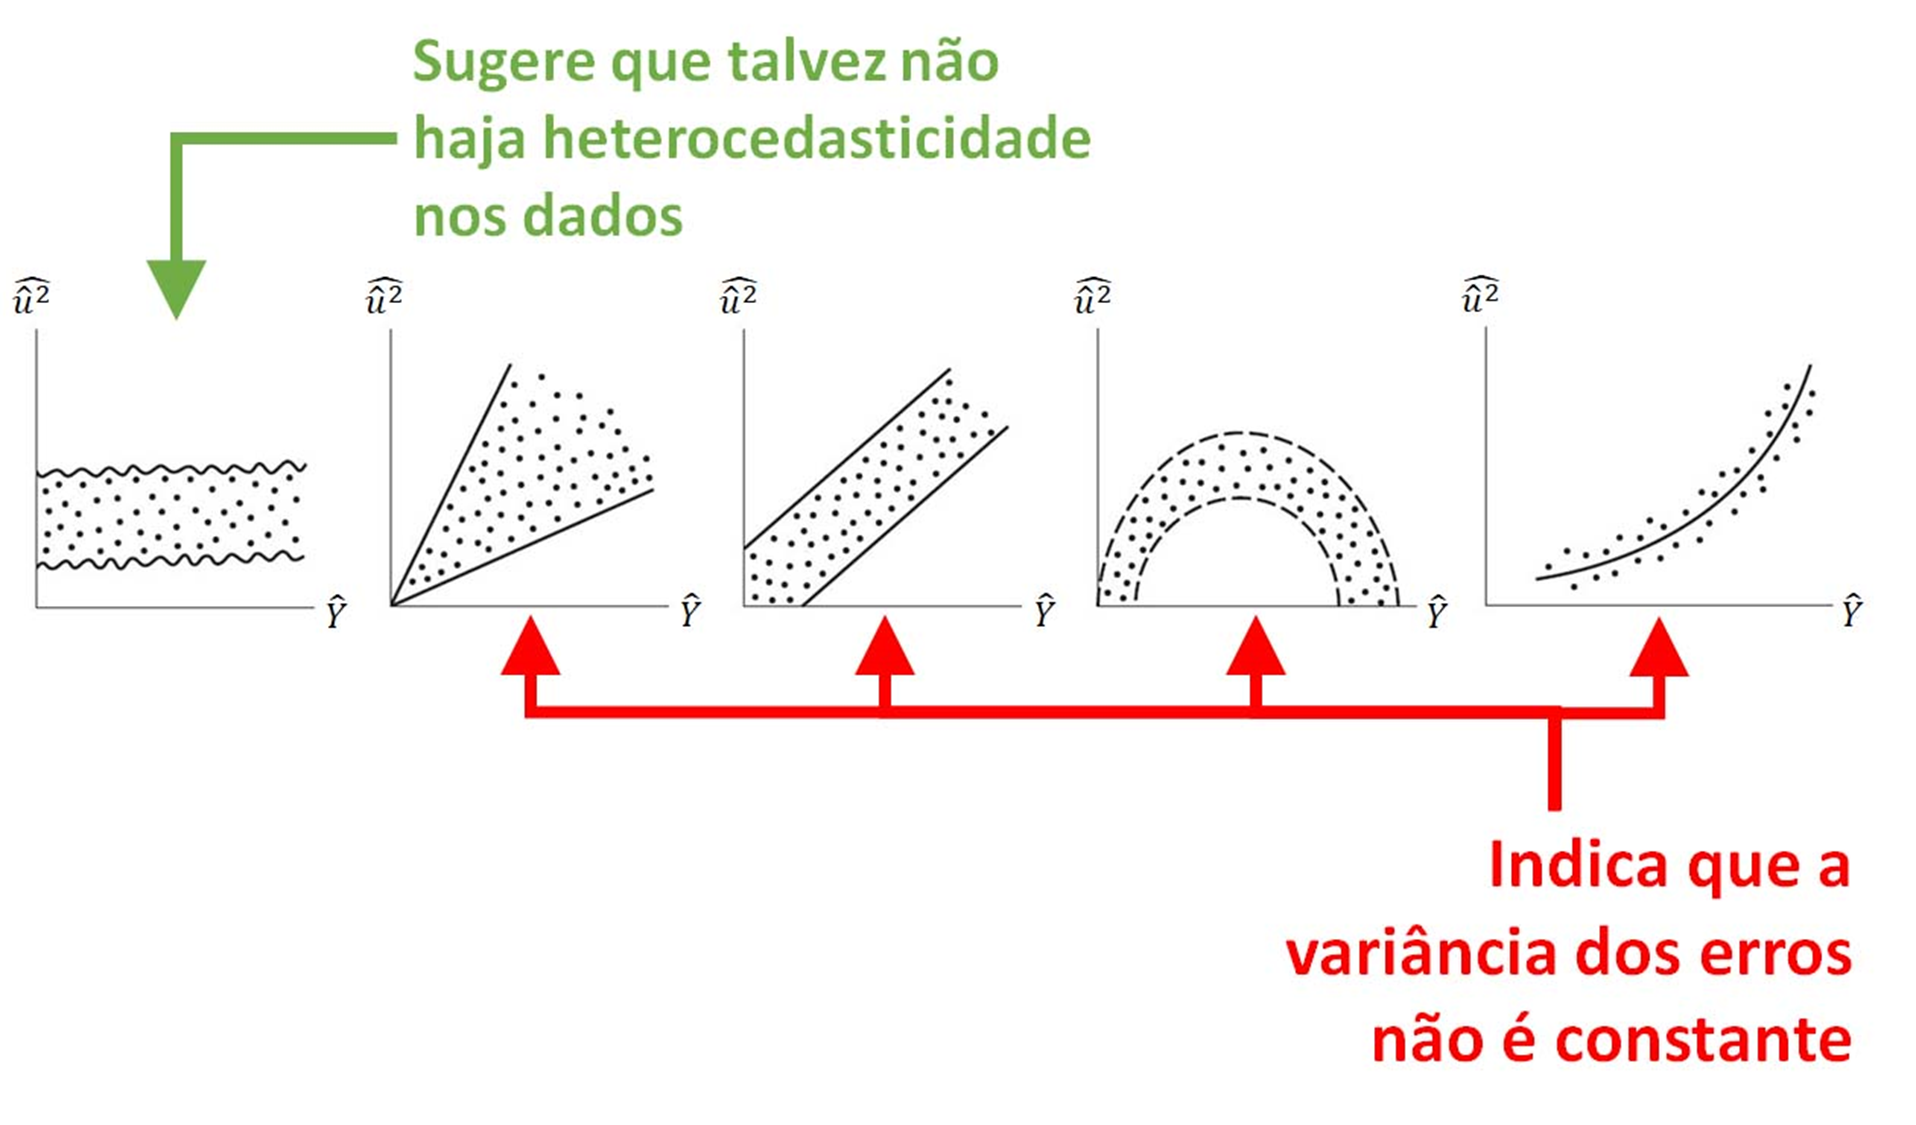